# Data Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
import pandas as pd

In [4]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True)
data= boston.frame

In [5]:
df= data.drop('MEDV', axis=1)

In [6]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [8]:
X=df[['LSTAT']].values

In [9]:
y=boston.target

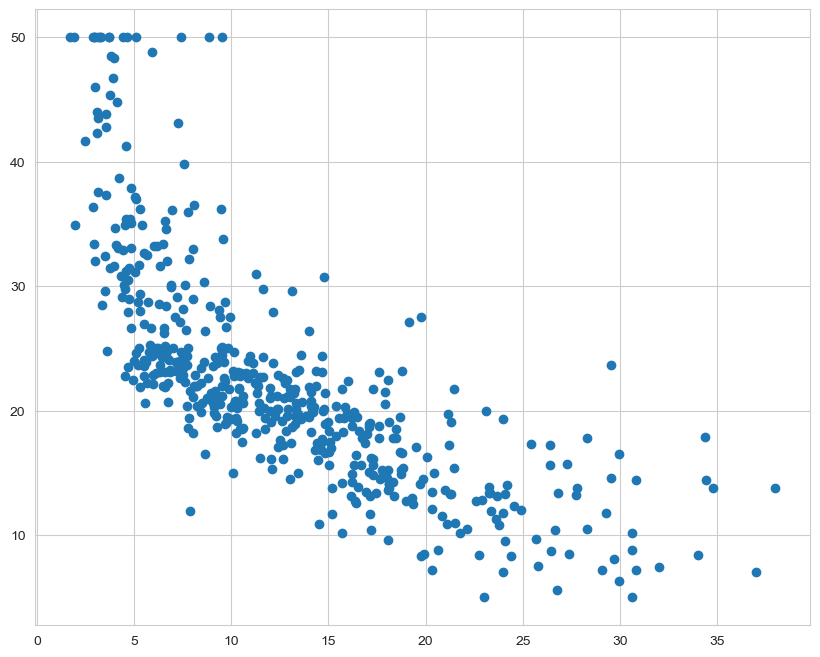

In [10]:
plt.figure(figsize=(10,8))
plt.scatter(X,y)

## Without Preprocessing

Text(0, 0.5, 'SSE')

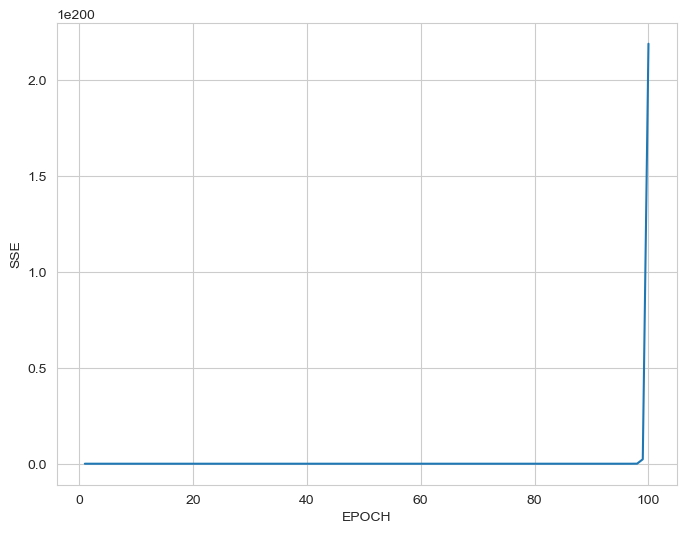

In [13]:
alpha=0.0001
w_=np.zeros(1+X.shape[1])
cost_=[]
n_=100

for i in range(n_):
    y_pred=np.dot(X,w_[1:])+w_[0]
    errors=(y-y_pred)

    w_[1:]+=alpha*X.T.dot(errors)
    w_[0]+=alpha*errors.sum()

    cost=(errors**2).sum()/2.0
    cost_.append(cost)

plt.figure(figsize=(8,6))
plt.plot(range(1,n_+1),cost_)
plt.xlabel('EPOCH')
plt.ylabel('SSE')

## With Preprocessing

In [16]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
sc_y=StandardScaler()
X_std=sc_x.fit_transform(X)
y_std=sc_y.fit_transform(y.values.reshape(-1,1)).flatten()

Text(0, 0.5, 'SSE')

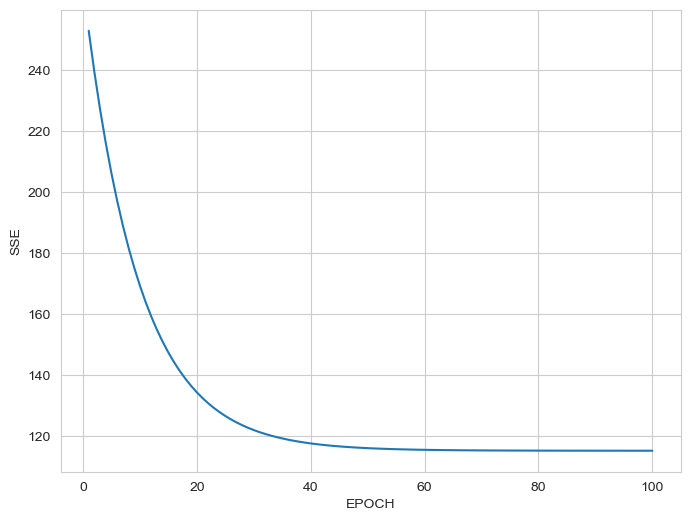

In [17]:
alpha=0.0001
w_=np.zeros(1+X_std.shape[1])
cost_=[]
n_=100

for i in range(n_):
    y_pred=np.dot(X_std,w_[1:])+w_[0]
    errors=(y_std-y_pred)

    w_[1:]+=alpha*X_std.T.dot(errors)
    w_[0]+=alpha*errors.sum()

    cost=(errors**2).sum()/2.0
    cost_.append(cost)

plt.figure(figsize=(8,6))
plt.plot(range(1,n_+1),cost_)
plt.xlabel('EPOCH')
plt.ylabel('SSE')

Before Scaling

(-40.0, 40.0)

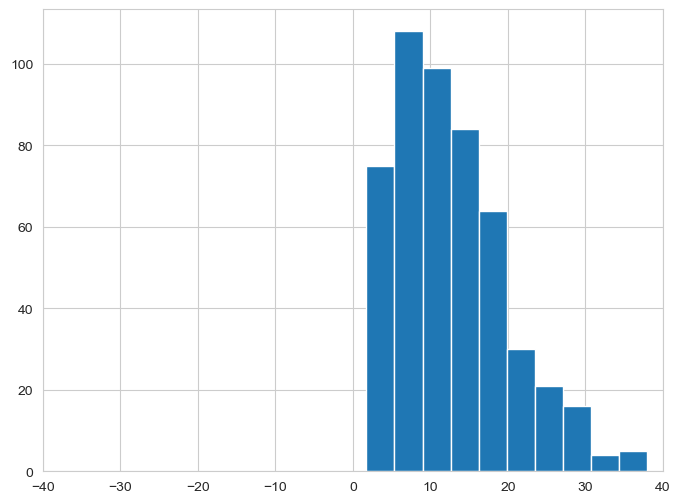

In [21]:
plt.figure(figsize=(8,6))
plt.hist(X)
plt.xlim(-40,40)

After Scaling

(-4.0, 4.0)

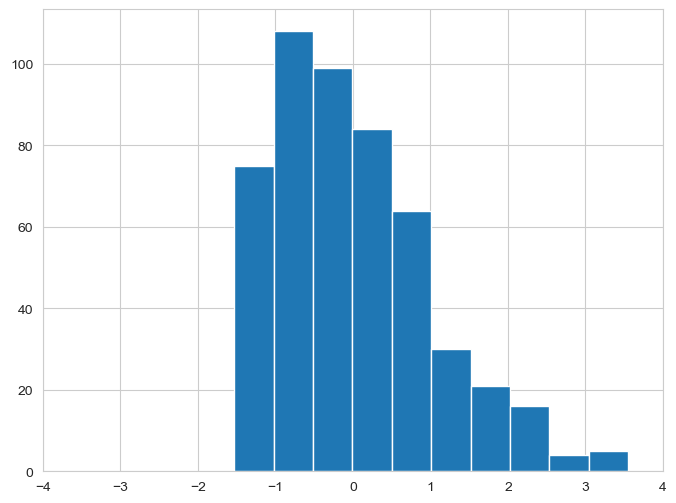

In [23]:
plt.figure(figsize=(8,6))
plt.hist(X_std)
plt.xlim(-4,4)

## Data PreProcessing
1.Standardization/mean Removal
2.Min-Max or scaling features to a range
3.Normalization
4.Binarization

In [31]:
from sklearn import preprocessing

In [32]:
X_train=np.array([[1.,-1.,2.],
                  [2.,0.,0.],
                  [0.,1.,-1.]])

In [33]:
X_train.mean(axis=0)

array([1.        , 0.        , 0.33333333])

## Standardization/Mean Removal/Variance Scaling

In [49]:
X_scaled=preprocessing.scale(X_train)
X_scaled

array([[ 0.        , -1.22474487,  1.33630621],
       [ 1.22474487,  0.        , -0.26726124],
       [-1.22474487,  1.22474487, -1.06904497]])

In [50]:
X_scaled.mean(axis=0)

array([0., 0., 0.])

In [51]:
X_scaled.std(axis=0)

array([1., 1., 1.])

Keeping in mind that if you scaled training data you must do likewise with your test data as well.However,your assumption is that the mean and variance must be varient between your train and test data.In $Scikit-Learn$ assists with a built-in utility function $StandardScaler$

In [52]:
scaler=preprocessing.StandardScaler().fit(X_train)
scaler

,copy,True
,with_mean,True
,with_std,True


In [53]:
scaler.mean_

array([1.        , 0.        , 0.33333333])

In [54]:
scaler.scale_

array([0.81649658, 0.81649658, 1.24721913])

In [55]:
scaler.transform(X_train)  #we are not gonna fit our test data rather we transform our train data
#verify in notes for clarification of fit(),transform().

array([[ 0.        , -1.22474487,  1.33630621],
       [ 1.22474487,  0.        , -0.26726124],
       [-1.22474487,  1.22474487, -1.06904497]])

(array([[0., 0., 0., 1., 0., 0., 1., 0., 0., 1.],
        [1., 0., 0., 1., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 1., 0., 0., 0., 0., 0., 1.]]),
 array([-1. , -0.7, -0.4, -0.1,  0.2,  0.5,  0.8,  1.1,  1.4,  1.7,  2. ]),
 <a list of 3 BarContainer objects>)

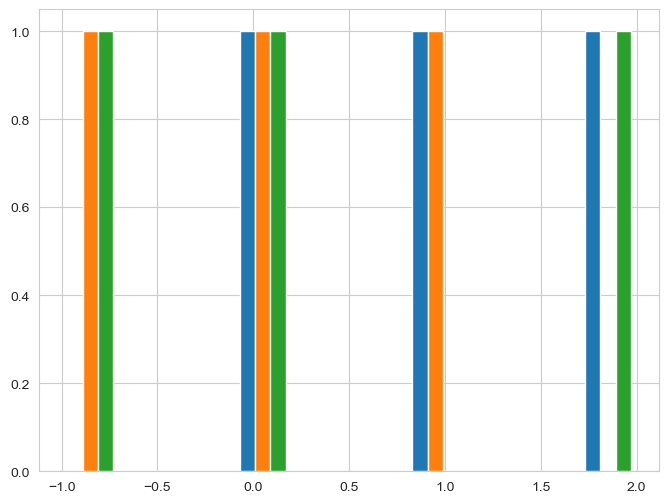

In [56]:
plt.figure(figsize=(8,6))
plt.hist(X_train)

You can now utilize the $transform$ for new dataset

In [57]:
X_test=[[-1.,1.,0.]]

In [58]:
scaler.transform(X_test)

array([[-2.44948974,  1.22474487, -0.26726124]])

If you “train” (fit) anything on test data, the evaluation becomes dishonest.   

Analogy (easy to remember):

$Exam analogy$  

Training data → Study material  

Scaler.fit() → Learning the rules 

Test data → Exam questions 

Would you:  

Learn new rules during the exam?  

❌ No  

You only apply what you learned.  

“We only transform test data using parameters learned from training data to avoid data leakage and ensure a fair estimate of generalization performance.”

## Min-Max or Scaling feature to a Range

## MinMax Scaler
Scale a data to the [0,1] range:

In [59]:
X_train=np.array([[1.,-1.,2.],
                  [2.,0.,0.],
                  [0.,1.,-1.]])

In [60]:
min_max_scaler=preprocessing.MinMaxScaler()

In [61]:
X_train_minmax=min_max_scaler.fit_transform(X_train)

In [62]:
X_train_minmax

array([[0.5       , 0.        , 1.        ],
       [1.        , 0.5       , 0.33333333],
       [0.        , 1.        , 0.        ]])

Now to  unseen data

In [63]:
X_test=np.array([[-3.,-1.,0.],
                 [2.,1.5,4.]])

In [64]:
X_test_minmax=min_max_scaler.transform(X_test)

In [65]:
X_test_minmax

array([[-1.5       ,  0.        ,  0.33333333],
       [ 1.        ,  1.25      ,  1.66666667]])

In the Above result of test data it exceeds the range which we have discussed previously of MinMaxScaler,But its expected due to the input test data values range.

## MaxAbsScaler

In [66]:
X_train=np.array([[1.,-1.,2.],
                  [2.,0.,0.],
                  [0.,1.,-1.]])

In [69]:
max_abs_scaler=preprocessing.MaxAbsScaler()
X_train_maxabs=max_abs_scaler.fit_transform(X_train)
X_train_maxabs

array([[ 0.5, -1. ,  1. ],
       [ 1. ,  0. ,  0. ],
       [ 0. ,  1. , -0.5]])

In [70]:
X_test=np.array([[-1.,-0.5,2.],
                 [0.,0.5,-0.6]])
X_test_maxabs=max_abs_scaler.transform(X_test)
X_test_maxabs

array([[-0.5, -0.5,  1. ],
       [ 0. ,  0.5, -0.3]])

## Normalization

In [72]:
X=[[1.,-1.,2.],
   [2.,0.,0.],
   [0.,1.,-1.]]
X_normalized=preprocessing.normalize(X,norm='l2')
X_normalized

array([[ 0.40824829, -0.40824829,  0.81649658],
       [ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.70710678, -0.70710678]])

Alternatively,  

The preprocessing module further provides a utility class Normalizer that implements the same operation using the Transformer API

In [73]:
normalizer=preprocessing.Normalizer().fit(X)
normalizer

,norm,'l2'
,copy,True


In [74]:
normalizer.transform(X)

array([[ 0.40824829, -0.40824829,  0.81649658],
       [ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.70710678, -0.70710678]])

In [75]:
normalizer.transform([[-1.,1.,0.]])

array([[-0.70710678,  0.70710678,  0.        ]])

## Binarization

In [90]:
from sklearn.preprocessing import Binarizer

In [91]:
X=[[1.,-1.,2.],
   [2.,0.,0.],
   [0.,1.,-1.]]
binarizer=preprocessing.Binarizer().fit(X)   #fit does nothing
binarizer

,threshold,0.0
,copy,True


In [92]:
Binarizer(copy=True,threshold=0.0)

,threshold,0.0
,copy,True


In [93]:
binarizer.transform(X)

array([[1., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [96]:
binarizer=preprocessing.Binarizer(threshold=-0.5)

In [97]:
binarizer.transform(X)

array([[1., 0., 1.],
       [1., 1., 1.],
       [1., 1., 0.]])

## Encoding categorical features  
Non-Numerical Data  
1.Label Encounter

In [98]:
source=['australia','hongkong','singapore','new zealand']

In [99]:
label_enc=preprocessing.LabelEncoder()
src=label_enc.fit_transform(source)

In [100]:
print("country to code mapping:\n")
for k,v in enumerate(label_enc.classes_):
    print(v,'\t',k)

country to code mapping:

australia 	 0
hongkong 	 1
new zealand 	 2
singapore 	 3


In [101]:
test_data=['hongkong','singapore','australia','new zealand']

In [102]:
result=label_enc.transform(test_data)

In [103]:
print(result)

[1 3 0 2]


## 2.One Hot/ One-of-K Encoding
usefull for dealing with sparse matrix  
uses one-of-k scheme  
* the process of turning a series of categorical responses into a set of binary result(0 or 1).

In [104]:
source

['australia', 'hongkong', 'singapore', 'new zealand']

In [105]:
src

array([0, 1, 3, 2])

In [106]:
from sklearn.preprocessing import OneHotEncoder

In [109]:
one_hot_enc=OneHotEncoder(sparse_output=False,categories='auto')
src=src.reshape(len(src),1)
one_hot=one_hot_enc.fit_transform(src)
print(one_hot)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]


In [110]:
invert_res=label_enc.inverse_transform([np.argmax(one_hot[0,:])])
print(invert_res)

['australia']


In [111]:
invert_res=label_enc.inverse_transform([np.argmax(one_hot[3,:])])
print(invert_res)

['new zealand']
